
===== Your Daily Intake =====
Protein: 72.40 g
Carbs: 311.40 g
Fat: 79.80 g
Calories: 2248.80 kcal
Iron: 12.40 mg

===== Required Intake =====
Protein: 55.20 g
Calories: 2070.00 kcal
Carbs: 207.00 g
Fat: 55.20 g
Iron: 17.00 mg

✅ Protein intake is good!

✅ Calories intake is good!

✅ Carbs intake is good!

✅ Fat intake is good!

⚠️ Low Iron: Need 4.60 more
Suggested foods:
→ Lotus stem pickle (Kamal kakdi ka achar) (20.57 Iron (mg))
→ Pav bhaji masala (12.84 Iron (mg))
→ Sesame ladoo (Til ke ladoo) (8.94 Iron (mg))

📊 Comparing your intake with recommended diet...


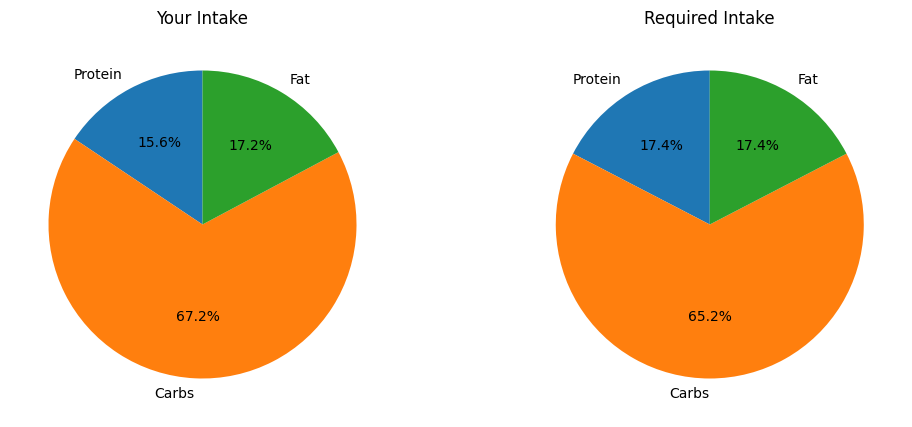

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("clean_data.csv")

# ===== USER INPUT =====
n = int(input("How many food items? "))

foods = []
quantities = []

for i in range(n):
    food = input(f"Enter food {i+1}: ")
    qty = int(input(f"Enter quantity for {food}: "))
    
    foods.append(food)
    quantities.append(qty)

# ===== CALCULATION =====
total_protein = 0
total_calories = 0
total_carbs = 0
total_fat = 0
total_iron = 0   # added

for i in range(len(foods)):
    item = df[df["Dish Name"].str.lower().str.contains(foods[i].lower())]

    if not item.empty:
        total_protein += item["Protein (g)"].values[0] * quantities[i]
        total_calories += item["Calories (kcal)"].values[0] * quantities[i]
        total_carbs += item["Carbohydrates (g)"].values[0] * quantities[i]
        total_fat += item["Fats (g)"].values[0] * quantities[i]
        total_iron += item["Iron (mg)"].values[0] * quantities[i]
    else:
        print(f"{foods[i]} not found")

# ===== PRINT =====
print("\n===== Your Daily Intake =====")
print(f"Protein: {total_protein:.2f} g")
print(f"Carbs: {total_carbs:.2f} g")
print(f"Fat: {total_fat:.2f} g")
print(f"Calories: {total_calories:.2f} kcal")
print(f"Iron: {total_iron:.2f} mg")

# ===== USER DETAILS =====
weight = float(input("\nEnter your weight (kg): "))

# ===== REQUIREMENTS (Approx values) =====
required_protein = weight * 0.8
required_calories = weight * 30
required_carbs = weight * 3
required_fat = weight * 0.8
required_iron = 17   # average adult

print("\n===== Required Intake =====")
print(f"Protein: {required_protein:.2f} g")
print(f"Calories: {required_calories:.2f} kcal")
print(f"Carbs: {required_carbs:.2f} g")
print(f"Fat: {required_fat:.2f} g")
print(f"Iron: {required_iron:.2f} mg")

# ===== SMART RECOMMENDATION 🔥 =====
def recommend(nutrient, total, required, column):
    deficit = required - total
    
    if deficit > 0:
        print(f"\n⚠️ Low {nutrient}: Need {deficit:.2f} more")
        
        foods_sorted = df.sort_values(by=column, ascending=False)
        
        print("Suggested foods:")
        count = 0
        for index, row in foods_sorted.iterrows():
            if row[column] > 5:
                print(f"→ {row['Dish Name']} ({row[column]} {column})")
                count += 1
            if count == 3:
                break
    else:
        print(f"\n✅ {nutrient} intake is good!")

# Apply for all nutrients
recommend("Protein", total_protein, required_protein, "Protein (g)")
recommend("Calories", total_calories, required_calories, "Calories (kcal)")
recommend("Carbs", total_carbs, required_carbs, "Carbohydrates (g)")
recommend("Fat", total_fat, required_fat, "Fats (g)")
recommend("Iron", total_iron, required_iron, "Iron (mg)")

# ===== PIE CHART 1: YOUR INTAKE =====
labels = ['Protein', 'Carbs', 'Fat']
your_values = [total_protein, total_carbs, total_fat]

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.pie(your_values, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title("Your Intake")

# ===== PIE CHART 2: REQUIRED INTAKE =====
print("\n📊 Comparing your intake with recommended diet...")
required_values = [required_protein, required_carbs, required_fat]

plt.subplot(1,2,2)
plt.pie(required_values, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title("Required Intake")

plt.show()


1. Add Meal
2. Show Status
3. Get Suggestions
4. Show Graph
5. Exit

✅ Meal added successfully!

1. Add Meal
2. Show Status
3. Get Suggestions
4. Show Graph
5. Exit

===== DAILY STATUS =====
Protein: 10.65 / 55.20
   ⚠️ Need 44.55 more
Carbs: 19.90 / 207.00
   ⚠️ Need 187.10 more
Fat: 169.20 / 55.20
   ✅ Completed
Calories: 1645.25 / 2070.00
   ⚠️ Need 424.75 more
Iron: 1.35 / 17.00
   ⚠️ Need 15.65 more

1. Add Meal
2. Show Status
3. Get Suggestions
4. Show Graph
5. Exit

===== SUGGESTIONS =====

Low protein → Suggested foods:
→ Gun powder chutney
→ Roast chicken

Low carbs → Suggested foods:
→ Mango murabba candy
→ Christmas star biscuit

Low calories → Suggested foods:
→ Soyabean muthias
→ Soyabean namak paras

Low iron → Suggested foods:
→ Lotus stem pickle (Kamal kakdi ka achar)
→ Pav bhaji masala

1. Add Meal
2. Show Status
3. Get Suggestions
4. Show Graph
5. Exit


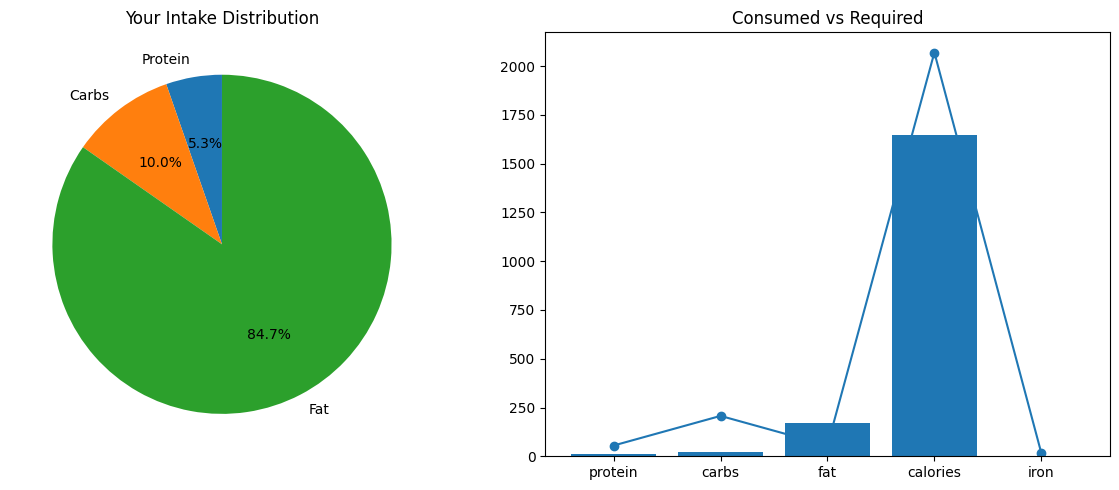


1. Add Meal
2. Show Status
3. Get Suggestions
4. Show Graph
5. Exit


In [ ]:
import pandas as pd


df = pd.read_csv("clean_data.csv")

# ===== USER DETAILS =====
weight = float(input("Enter your weight (kg): "))

required = {
    "protein": weight * 0.8,
    "carbs": weight * 3,
    "fat": weight * 0.8,
    "calories": weight * 30,
    "iron": 17
}

# ===== DAILY TRACKER =====
daily_total = {
    "protein": 0,
    "carbs": 0,
    "fat": 0,
    "calories": 0,
    "iron": 0
}
import matplotlib.pyplot as plt

def show_graphs():
    labels = ['Protein', 'Carbs', 'Fat']
    
    # ===== PIE CHART =====
    values = [
        daily_total["protein"],
        daily_total["carbs"],
        daily_total["fat"]
    ]

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=90)
    plt.title("Your Intake Distribution")

    # ===== BAR CHART (Consumed vs Required) =====
    nutrients = ["protein", "carbs", "fat", "calories", "iron"]
    
    consumed = [daily_total[n] for n in nutrients]
    required_vals = [required[n] for n in nutrients]

    x = range(len(nutrients))

    plt.subplot(1,2,2)
    plt.bar(x, consumed)
    plt.plot(x, required_vals, marker='o')
    
    plt.xticks(x, nutrients)
    plt.title("Consumed vs Required")

    plt.tight_layout()
    plt.show()

# ===== FUNCTION TO ADD MEAL =====
def add_meal():
    food = input("\nEnter food: ")
    qty = int(input("Enter quantity: "))

    item = df[df["Dish Name"].str.lower().str.contains(food.lower())]

    if not item.empty:
        daily_total["protein"] += item["Protein (g)"].values[0] * qty
        daily_total["carbs"] += item["Carbohydrates (g)"].values[0] * qty
        daily_total["fat"] += item["Fats (g)"].values[0] * qty
        daily_total["calories"] += item["Calories (kcal)"].values[0] * qty
        daily_total["iron"] += item["Iron (mg)"].values[0] * qty

        print("\n✅ Meal added successfully!")
    else:
        print("Food not found bro 😅")

# ===== FUNCTION TO SHOW STATUS =====
def show_status():
    print("\n===== DAILY STATUS =====")

    for key in daily_total:
        consumed = daily_total[key]
        req = required[key]
        remaining = req - consumed

        print(f"{key.capitalize()}: {consumed:.2f} / {req:.2f}")

        if remaining > 0:
            print(f"   ⚠️ Need {remaining:.2f} more")
        else:
            print("   ✅ Completed")

# ===== FUNCTION FOR RECOMMENDATION =====
def recommend():
    print("\n===== SUGGESTIONS =====")

    for nutrient, total in daily_total.items():
        deficit = required[nutrient] - total

        if deficit > 0:
            print(f"\nLow {nutrient} → Suggested foods:")

            sorted_df = df.sort_values(by={
                "protein": "Protein (g)",
                "carbs": "Carbohydrates (g)",
                "fat": "Fats (g)",
                "calories": "Calories (kcal)",
                "iron": "Iron (mg)"
            }[nutrient], ascending=False)

            count = 0
            for _, row in sorted_df.iterrows():
                if row[{
                    "protein": "Protein (g)",
                    "carbs": "Carbohydrates (g)",
                    "fat": "Fats (g)",
                    "calories": "Calories (kcal)",
                    "iron": "Iron (mg)"
                }[nutrient]] > 5:

                    print(f"→ {row['Dish Name']}")
                    count += 1

                if count == 2:
                    break

# ===== MAIN LOOP =====
while True:
    print("\n1. Add Meal")
    print("2. Show Status")
    print("3. Get Suggestions")
   
    print("4. Show Graph")
    print("5. Exit")


    # choice = input("Choose option: ")
    choice = input("Choose option: ").strip()

    if choice == "1":
        add_meal()
    elif choice == "2":
        show_status()
    elif choice == "3":
        recommend()
    elif choice == "4":
        show_graphs()
    elif choice == "5":
        break
    else:
        print("Invalid choice")